In [2]:
# Group cells by RBP
# We want to group cells by RBP expression.
# We take every RBP and cluster the cells based on the RBP expression using kmeans clustering.

library(tidyverse)
library(vroom)
library(data.table)
library(Biostrings)
library(ggpointdensity)
library(pheatmap)
library(preprocessCore)
library(purrr)
library(RColorBrewer)
library(ggpubr)
library(mclust)

reverse_complement <- function(dna_seq) {
  complement <- c("A" = "T", "T" = "A", "C" = "G", "G" = "C")
  nucleotides <- unlist(strsplit(dna_seq, ""))
  complement_nucleotides <- complement[nucleotides]
  reverse_complement_seq <- paste(rev(complement_nucleotides), collapse = "")
  return(reverse_complement_seq)
}

############# Look at Tau and PSI #################
# Calculate Tau for each gene.
calculate_tau <- function(row){
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau)
}
# upsilon is the metric for PSI. We add 1 so that values close to 0 will not be inflated.
calculate_upsilon <- function(row) {
  # Remove NA values from the row
  non_na_row <- row[!is.na(row)]
  # If the row is empty after removing NAs, return NA
  if (length(non_na_row) < 20) {
    return(NA)
  }
  # Add 1 to every value in the row.
  non_na_row <- non_na_row + 1
  # Normalize the row by dividing by the max value of the non-NA row
  norm_row <- non_na_row / max(non_na_row)
  # Calculate tau using the number of non-NA values
  tau <- sum(1 - norm_row) / (length(non_na_row) - 1)
  return(tau * 2)
}

output_filepath <- "/mnt/dawnccle2/figure_outputs"
dir.create(output_filepath, showWarnings = FALSE)

# This is the Broad gex.
all_gex <- fread("/mnt/dawnccle2/for_anisha/CCLE_expression.csv", sep = ",")
all_gex <- all_gex %>% 
  rename_with(~str_extract(., "^[^\\s]+")) %>% 
  # Rename V1 to DepMap_ID.
  dplyr::rename(DepMap_ID = "V1") 
# Sanger GEX
# all_gex <- fread("C:/Users/dawnxi/Dropbox (Harvard University)/02Splicing/latest/sanger_CCLE_gex_with_Broad_ID.csv")

predicted_RBP_Gerstberger <- fread("/mnt/dawnccle2/melange/data/RBP_possible_Gerstberger_NatRev2014.csv")
RBP_list1 <- predicted_RBP_Gerstberger %>% pull(`gene name`)
predicted_RBP_Hentze <- fread("/mnt/dawnccle2/melange/data/Hentze_2018_RBPs.csv")
RBP_list2 <- predicted_RBP_Hentze %>% pull(UNIQUE)
all_available_RBP <- intersect(colnames(all_gex), c(RBP_list1, RBP_list2))

# Filter to only the predicted RBPs
all_gex_RBP <- all_gex %>% select(DepMap_ID, all_of(all_available_RBP))

# Read in PSI table.
all_sample_reps <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_chimeric_rate_considering_included/WT_all_samples_PSI_count_table_filtered.csv")
all_sample_reps <- all_sample_reps %>% 
  # Mutate condition Kelly to KELLY
  mutate(condition = ifelse(condition == "Kelly", "KELLY", condition)) %>%
  group_by(condition, index_offset) %>% 
  summarise(PSI = mean(PSI, na.rm = T), n = n()) %>%
  filter(n >= 2) %>%
  select(-n) %>% 
  ungroup()

all_samples_wide <- all_sample_reps %>%
  pivot_wider(names_from = condition, values_from = PSI, values_fill = NA)

all_samples_mat <- as.matrix(all_samples_wide[, -1])
rownames(all_samples_mat) <- all_samples_wide$index_offset

cellline_metadata <- fread("/mnt/dawnccle2/for_anisha/cellline_data_full_metadata.csv") %>% 
  select(DepMap_ID, StrippedName) %>% distinct()
# Rename V1 in gex based on cellline_metadata
gex_formatted <- all_gex_RBP %>% 
  left_join(cellline_metadata, by = "DepMap_ID") %>% 
  select(-DepMap_ID) %>% 
  dplyr::rename(condition = "StrippedName") %>%
  filter(condition %in% c(colnames(all_samples_mat)))

# Get common cell lines in gex and all_samples_mat
common_cell_lines <- intersect(colnames(all_samples_mat), gex_formatted$condition)
#convert to matrix no condition column
gex_mat <- as.matrix(gex_formatted %>% select(-condition))
rownames(gex_mat) <- gex_formatted$condition
# Order matrices based on the common names
gex_mat_aligned <- gex_mat[common_cell_lines,]
# Order the all_samples_mat based on the names
all_samples_mat_aligned <- all_samples_mat[, common_cell_lines]
# subset to only rows that has <20% NA.
all_samples_mat_aligned <- all_samples_mat_aligned[rowMeans(is.na(all_samples_mat_aligned)) <= 0.2, ]


# Write the aligned matrix to output csv. 
# Create dir U:/processed_data/reprocess_250221/rbp_gex_outputs
# dir.create("/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs", showWarnings = FALSE)
# write.csv(t(all_samples_mat_aligned), "/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/df_all_samples_mat_aligned.csv")
# write.csv(gex_mat_aligned, "U:/processed_data/reprocess_250221/rbp_gex_outputs/df_gex_mat_aligned.csv")



Package 'mclust' version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.


Attaching package: ‘mclust’


The following object is masked from ‘package:purrr’:

    map


`summarise()` has grouped output by 'condition'. You can override using the
`.groups` argument.


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


[1] "Gene RBFOX1 had only 1 GMM cluster, using kmeans instead"
[1] "Gene DDX1 had only 1 GMM cluster, using kmeans instead"
[1] "Gene DDX43 had only 1 GMM cluster, using kmeans instead"
[1] "Gene APOB had only 1 GMM cluster, using kmeans instead"
[1] "Gene DAZL had only 1 GMM cluster, using kmeans instead"
[1] "Gene TDRD1 had only 1 GMM cluster, using kmeans instead"
[1] "Gene TLR8 had only 1 GMM cluster, using kmeans instead"
[1] "Gene LUZP4 had only 1 GMM cluster, using kmeans instead"
[1] "Gene ZFR2 had only 1 GMM cluster, using kmeans instead"
[1] "Gene APOBEC1 had only 1 GMM cluster, using kmeans instead"
[1] "Gene KHDRBS2 had only 1 GMM cluster, using kmeans instead"
[1] "Gene WARS2 had only 1 GMM cluster, using kmeans instead"
[1] "Gene UTP20 had only 1 GMM cluster, using kmeans instead"
[1] "Gene C4BPA had only 1 GMM cluster, using kmeans instead"
[1] "Gene APOBEC2 had only 1 GMM cluster, using kmeans instead"
[1] "Gene PIWIL1 had only 1 GMM cluster, using kmeans instead"
[1] "

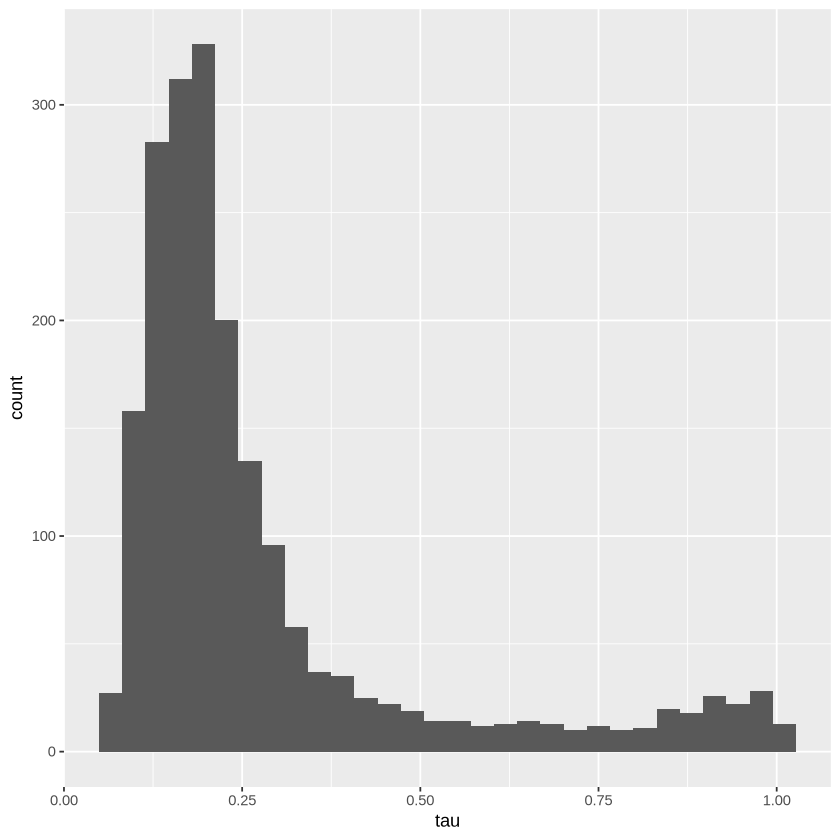

In [28]:
# Calculate tau for the gex values. 
tau_values <- apply(gex_mat_aligned, 2, calculate_tau)
# calculate dynamic range.
dynamic_range <- apply(gex_mat_aligned, 2, function(x) max(x, na.rm =T) - min(x, na.rm = T))
# convert the values to a df.
tau_df <- data.frame(gene = names(tau_values), tau = tau_values, dynamic_range = dynamic_range)
ggplot(tau_df, aes(x = tau)) +
  geom_histogram()
# Shortlist to tau >0.5.
shortlist_genes <- tau_df %>% filter(tau > 0.4) %>% pull(gene)
# Subset the gex_mat_aligned to the shortlist_genes.
gex_mat_aligned_shortlist <- gex_mat_aligned[, c(shortlist_genes)]
# Initialize a matrix to store cluster assignments
cluster_matrix_kmeans <- matrix(NA, nrow = nrow(gex_mat_aligned), ncol = length(shortlist_genes),
                         dimnames = list(rownames(gex_mat_aligned), shortlist_genes))

# Get max gene expression over all cells for all genes
max_gex <- apply(gex_mat_aligned_shortlist, 2, max, na.rm = T)
# Convert to df
max_gex_df <- data.frame(gene = names(max_gex), max_gex = max_gex)

# Loop through shortlisted genes and calculate clusters
for (gene in shortlist_genes) {
  gex_shortlist <- data.frame(gex = gex_mat_aligned[, gene], cell_line = rownames(gex_mat_aligned))
  
  # Perform k-means clustering on the gene expression values
  kmeans_result <- kmeans(gex_shortlist$gex, centers = 2)
  # Get number of samples in each cluster
  cluster_counts <- table(kmeans_result$cluster)
  
  # We want cluster 1 to be the big cluster. If cluster 2 is bigger, we switch the labels.
  if (cluster_counts[1] < cluster_counts[2]) {
    kmeans_result$cluster <- ifelse(kmeans_result$cluster == 1, 2, 1)
  }
  
  # Assign clusters to the respective cell lines in the cluster matrix
  cluster_matrix_kmeans[, gene] <- kmeans_result$cluster
  
  # Plot the gene expression as a barplot
  gex_shortlist$cluster <- as.character(kmeans_result$cluster)
  p <- ggplot(gex_shortlist, aes(x = cell_line, y = gex, fill = cluster)) +
    geom_bar(stat = "identity") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    labs(x = "Cell line", y = "Gene expression") +
    ggtitle(gene)
  
  # Save the barplot to a file
  ggsave(filename = paste0("/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/rbp_grouped_by_expression_kmeans/", gene, "_gene_expression_barplot.png"),
         plot = p, width = 8, height = 6)
}

############# GMM CLUSTERING ####################
library(mclust) # For Gaussian Mixture Modeling
# Initialize a matrix to store cluster assignments
cluster_matrix_gmm <- matrix(NA, nrow = nrow(gex_mat_aligned), ncol = length(shortlist_genes),
                         dimnames = list(rownames(gex_mat_aligned), shortlist_genes))
for (gene in shortlist_genes) {
  gex_shortlist <- data.frame(gex = gex_mat_aligned[, gene], cell_line = rownames(gex_mat_aligned))
  
  # Perform Gaussian Mixture Modeling
  gmm_result <- Mclust(gex_shortlist$gex, G = 2, modelNames = "V") # G = 2 specifies 2 clusters
  
  # Extract the predicted clusters
  gex_shortlist$cluster <- gmm_result$classification
  
  # Check if GMM found only 1 cluster
  if (length(unique(gex_shortlist$cluster)) < 2) {
    # If only 1 cluster, use kmeans instead
    print(paste("Gene", gene, "had only 1 GMM cluster, using kmeans instead"))
    kmeans_result <- kmeans(gex_shortlist$gex, centers = 2)
    gex_shortlist$cluster <- kmeans_result$cluster
  }
  
  # Count the number of samples in each cluster
  cluster_counts <- table(gex_shortlist$cluster)
  
  # Ensure cluster 1 is always the larger cluster
  if (length(cluster_counts) == 2 && cluster_counts[1] < cluster_counts[2]) {
    gex_shortlist$cluster <- ifelse(gex_shortlist$cluster == 1, 2, 1)
  }
  
  # Assign clusters to the respective cell lines in the cluster matrix
  cluster_matrix_gmm[, gene] <- gex_shortlist$cluster
  
  # Plot the gene expression as a barplot
  p <- ggplot(gex_shortlist, aes(x = cell_line, y = gex, fill = as.character(cluster))) +
    geom_bar(stat = "identity") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    labs(x = "Cell line", y = "Gene expression") +
    ggtitle(gene)
  
  # Save the barplot to a file
  ggsave(filename = paste0("/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/rbp_grouped_by_expression_GMM/", gene, "_gene_expression_barplot.png"),
         plot = p, width = 8, height = 6)
}
############# END GMM CLUSTERING ####################

In [42]:
write.csv(cluster_matrix_kmeans, "/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/RBP_cluster_matrix_kmeans.csv")
write.csv(cluster_matrix_gmm, "/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/RBP_cluster_matrix_gmm.csv")
# Write list of gene names to a txt file.
write.table(shortlist_genes, "/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/RBP_shortlist_genes.txt", row.names = FALSE, col.names = FALSE, quote = FALSE)

# Testing the cluster matrix code

In [ ]:
# ==== Load Packages ====
library(tidyverse)
library(vroom)
library(data.table)
library(future)
library(future.apply)
library(PAIRADISE)

# ==== Helper Functions ====

pad_with_zeros <- function(vec, target_len = 3) {
  if (length(vec) < target_len) {
    vec <- c(vec, rep(0, target_len - length(vec)))
  }
  return(vec)
}

get_idx_row <- function(idx, condition1_df, condition2_df) {
  condition1_index_df <- condition1_df %>% filter(index == idx) %>% arrange(sample)
  condition2_index_df <- condition2_df %>% filter(index == idx) %>% arrange(sample)

  I1 <- pad_with_zeros(condition1_index_df$count)
  S1 <- pad_with_zeros(condition1_index_df$skipped)
  I2 <- pad_with_zeros(condition2_index_df$count)
  S2 <- pad_with_zeros(condition2_index_df$skipped)

  data.frame(
    ExonID = idx,
    I1 = paste(I1, collapse = ","),
    S1 = paste(S1, collapse = ","),
    I2 = paste(I2, collapse = ","),
    S2 = paste(S2, collapse = ","),
    I_len = 1,
    S_len = 1
  )
}

# ==== Parse Command Line Args ====
args <- commandArgs(trailingOnly = TRUE)
genename <- args[1]  # e.g. "RBFOX1"
output_filename <- args[2]  # e.g. "RBFOX1_paradise.tsv"
genename <- "RBFOX1"

# ==== Load Data ====

all_sample_reps <- fread("/mnt/dawnccle2/processed_data/reprocess_250221/count_normalized_chimeric_rate_considering_included/WT_all_samples_PSI_count_table.csv")
all_sample_reps <- all_sample_reps %>%
  filter(condition != "K562WT" & condition != "K562K700E") %>%
  mutate(index_offset = paste0(index, "__", offset))

rbp_clusters <- read_csv("/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/RBP_cluster_matrix_gmm.csv")
colnames(rbp_clusters)[1] <- "celltype"

# ==== Extract Cell Types by Cluster ====
gene_shortlist <- rbp_clusters[, c("celltype", genename)]
colnames(gene_shortlist)[2] <- "cluster"

cluster1_condition <- gene_shortlist %>%
  filter(cluster == 1) %>%
  mutate(celltype = str_to_upper(celltype)) %>%
  pull(celltype)

cluster2_condition <- gene_shortlist %>%
  filter(cluster == 2) %>%
  mutate(celltype = str_to_upper(celltype)) %>%
  pull(celltype)

# ==== Filter Input Data ====
condition1_df <- all_sample_reps %>% filter(condition %in% cluster1_condition)
condition2_df <- all_sample_reps %>% filter(condition %in% cluster2_condition)
unique_indices <- unique(condition1_df$index)

# ==== Parallel Setup ====
# options(future.globals.maxSize = 10 * 1024^3)  # 10 GiB limit
plan(multisession, workers = availableCores() - 10)

# ==== Run Parallelized Formatting ====
paradise_df <- future_lapply(
  unique_indices,
  function(idx) get_idx_row(idx, condition1_df, condition2_df),
  future.globals = list(
    get_idx_row = get_idx_row,
    pad_with_zeros = pad_with_zeros,
    condition1_df = condition1_df,
    condition2_df = condition2_df
  )
) %>% bind_rows()

# ==== Output ====
# write_tsv(paradise_df, file = output_filename)
print(paste("Finished writing", output_filename))

New names:
• `` -> `...1`
Rows: 41 Columns: 319
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): ...1
dbl (318): YBX2, DCN, SAMD4A, RNASET2, CELF2, DDX3Y, HEATR6, SIDT1, MOV10L1,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [53]:
genename

[1] "/home/unix/dawnxi/.local/share/jupyter/runtime/kernel-v37a344b84a60575d92f3e89fbb757575814598980.json"

index,mode,offset,sample,condition,included_count,skipped_count,index_offset
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539,INCLUDED,0:-1:0,CH3-1_A1-rep1,CH3-1_A1,6,0,ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539__0:-1:0
ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539,INCLUDED,0:0:0,CH3-1_A1-rep1,CH3-1_A1,305,0,ENSG00000000003.15;TSPAN6;chrX-100632484-100632568-100630758-100630866-100633404-100633539__0:0:0
ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252,INCLUDED,-1:0:0,CH3-1_A1-rep1,CH3-1_A1,8,0,ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252__-1:0:0
ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252,INCLUDED,0:-1:0,CH3-1_A1-rep1,CH3-1_A1,0,0,ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252__0:-1:0
ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252,INCLUDED,0:0:0,CH3-1_A1-rep1,CH3-1_A1,347,0,ENSG00000000003.15;TSPAN6;chrX-100633930-100634029-100632484-100632568-100635177-100635252__0:0:0
ENSG00000000003.15;TSPAN6;chrX-100635177-100635252-100633930-100634029-100635557-100635746,INCLUDED,0:0:0,CH3-1_A1-rep1,CH3-1_A1,23,5,ENSG00000000003.15;TSPAN6;chrX-100635177-100635252-100633930-100634029-100635557-100635746__0:0:0
ENSG00000000419.14;DPM1;chr20-50945736-50945762-50942030-50942126-50945846-50945861,INCLUDED,0:0:0,CH3-1_A1-rep1,CH3-1_A1,205,24,ENSG00000000419.14;DPM1;chr20-50945736-50945762-50942030-50942126-50945846-50945861__0:0:0
ENSG00000000419.14;DPM1;chr20-50948628-50948662-50945736-50945923-50955185-50955285,INCLUDED,0:0:0,CH3-1_A1-rep1,CH3-1_A1,2,4,ENSG00000000419.14;DPM1;chr20-50948628-50948662-50945736-50945923-50955185-50955285__0:0:0
ENSG00000000457.14;SCYL3;chr1-169870254-169870357-169868927-169869039-169873695-169873752,INCLUDED,-1:0:0,CH3-1_A1-rep1,CH3-1_A1,2,0,ENSG00000000457.14;SCYL3;chr1-169870254-169870357-169868927-169869039-169873695-169873752__-1:0:0


In [26]:
rbp_clusters <- read_csv("/mnt/dawnccle2/processed_data/reprocess_250221/rbp_gex_outputs/RBP_cluster_matrix_gmm.csv") 
# rename column 1 to cell line
colnames(rbp_clusters)[1] <- "celltype"

# Extract columns celltype and genename. Genename is the gene name of the RBP, which is a colname
genename <- "CELF3"
gene_shortlist <- rbp_clusters[, c("celltype", genename)]
colnames(gene_shortlist)[2] <- "cluster"

cluster1_condition <- gene_shortlist %>% filter(cluster == 1) %>% mutate(celltype = str_to_upper(celltype)) %>% pull(celltype)
cluster2_condition <- gene_shortlist %>% filter(cluster == 2) %>% mutate(celltype = str_to_upper(celltype)) %>% pull(celltype)

gene_shortlist


New names:
• `` -> `...1`
Rows: 41 Columns: 319
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): ...1
dbl (236): YBX2, DCN, SAMD4A, RNASET2, CELF2, DDX3Y, HEATR6, SIDT1, MOV10L1,...
lgl  (82): RBFOX1, DDX1, DDX43, APOB, DAZL, TDRD1, TLR8, LUZP4, ZFR2, APOBEC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


celltype,cluster
<chr>,<dbl>
769P,1
786O,1
8MGBA,1
A172,1
A375,1
ACHN,1
CAL120,1
COGN278,2
COLO783,1


In [ ]:
# Calculate tau for the gex values. 
tau_values <- apply(gex_mat_aligned, 2, calculate_tau)
# calculate dynamic range.
dynamic_range <- apply(gex_mat_aligned, 2, function(x) max(x, na.rm =T) - min(x, na.rm = T))
# convert the values to a df.
tau_df <- data.frame(gene = names(tau_values), tau = tau_values, dynamic_range = dynamic_range)
ggplot(tau_df, aes(x = tau)) +
  geom_histogram()
# Shortlist to tau >0.5 and dynamic_range > 2 in the gex_mat_aligned.
shortlist_genes <- tau_df %>% filter(tau > 0.4) %>% pull(gene)
# Subset the gex_mat_aligned to the shortlist_genes.
gex_mat_aligned_shortlist <- gex_mat_aligned[, c(shortlist_genes)]

# Initialize a matrix to store cluster assignments
cluster_matrix <- matrix(NA, nrow = nrow(gex_mat_aligned), ncol = length(shortlist_genes),
                         dimnames = list(rownames(gex_mat_aligned), shortlist_genes))

# Get max gene expression over all cells for all genes
max_gex <- apply(gex_mat_aligned_shortlist, 2, max, na.rm = T)
# Convert to df
max_gex_df <- data.frame(gene = names(max_gex), max_gex = max_gex)

# Loop through shortlisted genes and calculate clusters
for (gene in shortlist_genes) {
  gex_shortlist <- data.frame(gex = gex_mat_aligned[, gene], cell_line = rownames(gex_mat_aligned))
  
  # Perform k-means clustering on the gene expression values
  kmeans_result <- kmeans(gex_shortlist$gex, centers = 2)
  # Get number of samples in each cluster
  cluster_counts <- table(kmeans_result$cluster)
  
  # We want cluster 1 to be the big cluster. If cluster 2 is bigger, we switch the labels.
  if (cluster_counts[1] < cluster_counts[2]) {
    kmeans_result$cluster <- ifelse(kmeans_result$cluster == 1, 2, 1)
  }
  
  # Assign clusters to the respective cell lines in the cluster matrix
  cluster_matrix[, gene] <- kmeans_result$cluster
  
  # Plot the gene expression as a barplot
  gex_shortlist$cluster <- as.character(kmeans_result$cluster)
  p <- ggplot(gex_shortlist, aes(x = cell_line, y = gex, fill = cluster)) +
    geom_bar(stat = "identity") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
    labs(x = "Cell line", y = "Gene expression") +
    ggtitle(gene)
  
  # Save the barplot to a file
  ggsave(filename = paste0("~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/figure_outputs/gex_broad/", gene, "_gene_expression_barplot.png"),
         plot = p, width = 8, height = 6)
}

############# GMM CLUSTERING ####################
# library(mclust) # For Gaussian Mixture Modeling
# 
# for (gene in shortlist_genes) {
#   gex_shortlist <- data.frame(gex = gex_mat_aligned[, gene], cell_line = rownames(gex_mat_aligned))
#   
#   # Perform Gaussian Mixture Modeling
#   gmm_result <- Mclust(gex_shortlist$gex, G = 2) # G = 2 specifies 2 clusters
#   
#   # Extract the predicted clusters
#   gex_shortlist$cluster <- gmm_result$classification
#   
#   # Count the number of samples in each cluster
#   cluster_counts <- table(gex_shortlist$cluster)
#   
#   # Ensure cluster 1 is always the larger cluster
#   if (cluster_counts[1] < cluster_counts[2]) {
#     gex_shortlist$cluster <- ifelse(gex_shortlist$cluster == 1, 2, 1)
#   }
#   
#   # Assign clusters to the respective cell lines in the cluster matrix
#   cluster_matrix[, gene] <- gex_shortlist$cluster
#   
#   # Plot the gene expression as a barplot
#   p <- ggplot(gex_shortlist, aes(x = cell_line, y = gex, fill = as.character(cluster))) +
#     geom_bar(stat = "identity") +
#     theme_minimal() +
#     theme(axis.text.x = element_text(angle = 90, hjust = 1)) +
#     labs(x = "Cell line", y = "Gene expression") +
#     ggtitle(gene)
#   
#   # Save the barplot to a file
#   ggsave(filename = paste0("~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/figure_outputs/gex_broad_GMM/", gene, "_gene_expression_barplot.png"),
#          plot = p, width = 8, height = 6)
# }
############# END GMM CLUSTERING ####################



# Save the cluster matrix to a CSV file
write.csv(cluster_matrix, "~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/RBP_cluster_matrix.csv")

# Optional: Inspect the first few rows of the cluster matrix
head(cluster_matrix)
# Save the list of genes as a txt file with no row names and no quotesf
write.table(shortlist_genes, "~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/RBP_shortlist_genes.txt", row.names = FALSE, col.names = FALSE, quote = FALSE)


########### Look at the different PSI by RBP ############
library(tidyverse)
library(vroom)
library(data.table)
library(Biostrings)
library(ggpointdensity)
library(pheatmap)
library(gridExtra)
library(ggrepel)

combined_psi <- fread("~/Dropbox (Harvard University)/02Splicing/latest/all_samples_RBP_PSI_combined_output_broad.tsv")
# combined_psi <- fread("~/Dropbox (Harvard University)/02Splicing/latest/Nova240826_3ss_combined_output_indiv.tsv")
calculate_ratio <- function(I, S) {
  I_values <- as.numeric(unlist(strsplit(I, ",")))
  S_values <- as.numeric(unlist(strsplit(S, ",")))
  ratio <- I_values / (I_values + S_values)
  # Check if any of the values are NaN
  if (any(is.nan(ratio))) {
    ratio[is.nan(ratio)] <- NA
  }
  return(paste(round(ratio,3), collapse = ","))
}

calculate_average <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  average <- mean(PSI_values, na.rm = T)
  return(round(average, 3))
}

get_max_PSI <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  max_PSI <- max(PSI_values, na.rm = T)
  return(round(max_PSI, 3))
}

get_min_PSI <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  min_PSI <- min(PSI_values, na.rm = T)
  return(round(min_PSI, 3))
}

calculate_average_count_sum <- function(I, S){
  I_values <- as.numeric(unlist(strsplit(I, ",")))
  S_values <- as.numeric(unlist(strsplit(S, ",")))
  total_sum <- I_values + S_values
  average_count_sum <- mean(total_sum)
  return(round(average_count_sum, 0))
}

get_num_obs <- function(PSI){
  PSI_values <- as.numeric(unlist(strsplit(PSI, ",")))
  num_obs <- length(PSI_values)
  return(num_obs)
}

# Apply the function to the data frame
combined_psi <- combined_psi %>%
  mutate(
    PSI1 = mapply(calculate_ratio, I1, S1),
    PSI2 = mapply(calculate_ratio, I2, S2)
  ) %>% 
  mutate(
    PSI1_average = mapply(calculate_average, PSI1),
    PSI2_average = mapply(calculate_average, PSI2)
  ) %>%
  mutate(PSI_diff = PSI1_average - PSI2_average) %>% 
  mutate(
    count_sum_average1 = mapply(calculate_average_count_sum, I1, S1),
    count_sum_average2 = mapply(calculate_average_count_sum, I2, S2)
  ) %>% mutate(PSI_ratio = PSI1_average / PSI2_average) %>% 
  mutate(PSI_reverse_ratio = (1-PSI1_average)/(1-PSI2_average)) %>% 
  mutate(max_PSI1 = mapply(get_max_PSI, PSI1), max_PSI2 = mapply(get_max_PSI, PSI2)) %>% 
  mutate(min_PSI1 = mapply(get_min_PSI, PSI1), min_PSI2 = mapply(get_min_PSI, PSI2)) %>%
  mutate(num_obs_PSI1 = mapply(get_num_obs, PSI1), num_obs_PSI2 = mapply(get_num_obs, PSI2)) 


combined_psi_filtered <- combined_psi %>% 
  filter(count_sum_average1 >30) %>% 
  filter(count_sum_average2 > 30) %>% 
  mutate(log2_PSI_ratio = log2(PSI_ratio), log2_PSI_reverse_ratio = log2(PSI_reverse_ratio))
write_csv(combined_psi_filtered, "~/Dropbox (Harvard University)/02Splicing/latest/all_samples_RBP_PSI_filtered.csv")



top_seq <- combined_psi_filtered %>% filter(abs(log2_PSI_ratio) > 2 | abs(log2_PSI_reverse_ratio) > 2)
num_obs_per_seq <- top_seq %>% group_by(ExonID) %>% summarise(num_obs = n())
num_obs_per_gene <- combined_psi %>% group_by(Folder) %>% summarise(num_obs = n()) %>% arrange(desc(num_obs))
# Merge with max_gex_df
num_obs_per_seq <- num_obs_per_seq %>% left_join(max_gex_df, by = c("ExonID" = "gene"))
num_obs_per_gene <- num_obs_per_gene %>% left_join(max_gex_df, by = c("Folder" = "gene"))

top_seq <- top_seq %>% left_join(num_obs_per_seq, by = "ExonID") %>% filter(num_obs > 1)

cluster_matrix <- read_csv("~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/RBP_cluster_matrix.csv")
colnames(cluster_matrix)[1] <- "cellline"
cluster_df <- tibble(
  gene = character(),
  cluster1_cellline = character(),
  cluster2_cellline = character()
)

# Loop through each gene (column) to populate the dataframe
for (gene in colnames(cluster_matrix)[-1]) {  # Exclude the "cellline" column
  # Filter for cluster 1 and 2, sort alphabetically, and concatenate with commas
  cluster_1 <- cluster_matrix %>%
    filter(!!sym(gene) == 1) %>%
    pull(cellline) %>%
    sort() %>%  # Sort alphabetically
    paste(collapse = ",")
  
  cluster_2 <- cluster_matrix %>%
    filter(!!sym(gene) == 2) %>%
    pull(cellline) %>%
    sort() %>%  # Sort alphabetically
    paste(collapse = ",")
  
  # Add the results to the dataframe
  cluster_df <- cluster_df %>%
    add_row(
      gene = gene,
      cluster1_cellline = cluster_1,
      cluster2_cellline = cluster_2
    )
}

sorted_cluster_df <- cluster_df %>%
  mutate(
    sorted_cluster1 = if_else(cluster1_cellline > cluster2_cellline, cluster2_cellline, cluster1_cellline),
    sorted_cluster2 = if_else(cluster1_cellline > cluster2_cellline, cluster1_cellline, cluster2_cellline)
  ) %>%
  select(gene, sorted_cluster1, sorted_cluster2)

cluster_group_counts <- cluster_df %>%
  rowwise() %>%
  mutate(
    sorted_cluster1 = if_else(cluster1_cellline > cluster2_cellline, cluster2_cellline, cluster1_cellline),
    sorted_cluster2 = if_else(cluster1_cellline > cluster2_cellline, cluster1_cellline, cluster2_cellline)
  ) %>%
  ungroup() %>%
  group_by(sorted_cluster1, sorted_cluster2) %>%
  summarise(gene_count = n(), .groups = "drop") %>%
  arrange(desc(gene_count))

# merge num_obs_per_gene and cluster_df
num_obs_per_gene_cluster <- num_obs_per_gene %>% left_join(sorted_cluster_df, by = c("Folder" = "gene"))
# Merge with max_gex_df
num_obs_per_gene_cluster <- num_obs_per_gene_cluster %>% 
  # Filter for gex > 0.2 because the very low ones I think are fake
  filter(max_gex > 0.2)

write.csv(num_obs_per_gene_cluster, "~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/RBP_num_obs_per_gene_cluster.csv")
#################### All RBP individually ###################
library(data.table)
library(dplyr)
library(ggplot2)
library(ggrepel)
library(stringr)

# Define the RBPs and file base path
base_path <- "/Volumes/broad_dawnccle/processed_data/missplicing_processed_df/V6/RBP_type_PSI_broad/"
# Get folders in the base path
rbps <- list.dirs(base_path, full.names = FALSE, recursive = FALSE)

# Get from those that are significant only. 
all_rbps <- combined_psi %>% 
  group_by(Folder) %>% 
  summarise(n = n(), num_obs_PSI1 =  mean(num_obs_PSI1), num_obs_PSI2 = mean(num_obs_PSI2)) %>%
  arrange(desc(n)) 


# Define the save path base
save_path_base <- "~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/figure_outputs/all_RBP_groups_broad/"

# Loop through each RBP
for (rbp in all_rbps$Folder) {
# for (rbp in c("RBMXL3")){ 
  # Construct the file path dynamically
  file_path <- file.path(base_path, paste0(rbp),
                         paste0(rbp, "_rMATS_Result_lineage_P.FDR.txt"))
  
  # Read and process the data
  all_df <- fread(file_path) %>%
    mutate(
      PSI1 = mapply(calculate_ratio, I1, S1),
      PSI2 = mapply(calculate_ratio, I2, S2),
      PSI1_average = mapply(calculate_average, PSI1),
      PSI2_average = mapply(calculate_average, PSI2),
      PSI_diff = PSI1_average - PSI2_average,
      count_sum_average1 = mapply(calculate_average_count_sum, I1, S1),
      count_sum_average2 = mapply(calculate_average_count_sum, I2, S2),
      PSI_ratio = PSI1_average / PSI2_average,
      PSI_reverse_ratio = (1 - PSI1_average) / (1 - PSI2_average),
      max_PSI1 = mapply(get_max_PSI, PSI1),
      max_PSI2 = mapply(get_max_PSI, PSI2),
      min_PSI1 = mapply(get_min_PSI, PSI1),
      min_PSI2 = mapply(get_min_PSI, PSI2),
      num_obs_PSI1 = mapply(get_num_obs, PSI1),
      num_obs_PSI2 = mapply(get_num_obs, PSI2),
      gene_name = map_chr(ExonID, ~str_split(.x, ";")[[1]][2])
    ) %>%
    filter(count_sum_average1 > 30 & count_sum_average2 > 30) %>%
    mutate(
      FDR = ifelse(FDR == 0, 1e-15, FDR),
      top_genes = ifelse(abs(PSI_diff) > 0.2 & (-log10(FDR) > -log10(0.01)), gene_name, NA),
      is_top_gene = ifelse(!is.na(top_genes), "top_gene", "other")
    )
  
  # Generate the plot
  plot <- ggplot(all_df, aes(x = log2(PSI_ratio), y = -log10(FDR), color = is_top_gene)) +
    geom_point() +
    geom_vline(xintercept = c(-0.2, 0.2), linetype = "dashed") +
    geom_hline(yintercept = -log10(0.01), linetype = "dashed") +
    geom_text_repel(aes(label = top_genes), na.rm = TRUE) +
    scale_color_manual(values = c("top_gene" = "red", "other" = "grey")) +
    theme_bw() +
    xlab("log2(PSI ratio)") +
    xlim(-6,6) + 
    ylim(0,15) + 
    ggtitle(paste("RBP clusters for", toupper(rbp), "cluster 1 n =", max(all_df$num_obs_PSI1), "cluster 2 n=", max(all_df$num_obs_PSI2)))
  
  # Construct the save path dynamically
  save_path <- file.path(save_path_base, paste0(toupper(rbp), "_volcano_plot_ratio.png"))
  
  # Save the plot
  ggsave(save_path, plot, width = 10, height = 6, units = "in", dpi = 300)
}

CELF3 <- all_df


####### Look at mutant RBP3 ########
# Define the RBPs and file base path
rbps <- paste0("rbp", 1:12)
base_path <- "/Volumes/broad_dawnccle/processed_data/missplicing_processed_df/novaseq241106/pairadise_indiv_PSI"

# Define the save path base
save_path_base <- "~/Dropbox (Harvard University)/02Splicing/SplicingManuscript/figure_outputs"

# Loop through each RBP
for (rbp in c("rbp3")) {
  # Construct the file path dynamically
  file_path <- file.path(base_path, paste0("splicelib_hek_no_dox_", rbp, "_splicelib_hek_dox_", rbp),
                         paste0("splicelib_hek_no_dox_", rbp, "_splicelib_hek_dox_", rbp, "_rMATS_Result_P.FDR.txt"))
  
  # Read and process the data
  all_df <- fread(file_path) %>%
    mutate(
      PSI1 = mapply(calculate_ratio, I1, S1),
      PSI2 = mapply(calculate_ratio, I2, S2),
      PSI1_average = mapply(calculate_average, PSI1),
      PSI2_average = mapply(calculate_average, PSI2),
      PSI_diff = PSI1_average - PSI2_average,
      count_sum_average1 = mapply(calculate_average_count_sum, I1, S1),
      count_sum_average2 = mapply(calculate_average_count_sum, I2, S2),
      PSI_ratio = PSI1_average / PSI2_average,
      PSI_reverse_ratio = (1 - PSI1_average) / (1 - PSI2_average),
      max_PSI1 = mapply(get_max_PSI, PSI1),
      max_PSI2 = mapply(get_max_PSI, PSI2),
      min_PSI1 = mapply(get_min_PSI, PSI1),
      min_PSI2 = mapply(get_min_PSI, PSI2),
      num_obs_PSI1 = mapply(get_num_obs, PSI1),
      num_obs_PSI2 = mapply(get_num_obs, PSI2),
      gene_name = map_chr(ExonID, ~str_split(.x, ";")[[1]][2])
    ) %>%
    filter(count_sum_average1 > 30 & count_sum_average2 > 30) %>%
    mutate(
      FDR = ifelse(FDR == 0, 1e-15, FDR),
      top_genes = ifelse(abs(PSI_diff) > 0.2 & (-log10(FDR) > -log10(0.01)), gene_name, NA),
      is_top_gene = ifelse(!is.na(top_genes), "top_gene", "other")
    )
  
  
  # Generate the plot
  plot <- ggplot(all_df, aes(x = log2(PSI_ratio), y = -log10(FDR), color = is_top_gene)) +
    geom_point() +
    geom_vline(xintercept = c(-0.2, 0.2), linetype = "dashed") +
    geom_hline(yintercept = -log10(0.01), linetype = "dashed") +
    geom_text_repel(aes(label = top_genes), na.rm = TRUE) +
    scale_color_manual(values = c("top_gene" = "red", "other" = "grey")) +
    theme_bw() +
    xlab("log2(PSI ratio)") +
    ggtitle(paste("No Dox vs Dox for", toupper(rbp)))
  
  # Construct the save path dynamically
  save_path <- file.path(save_path_base, paste0(toupper(rbp), "_volcano_plot_ratio.png"))
  
  # Save the plot
  ggsave(save_path, plot, width = 10, height = 6, units = "in", dpi = 300)
}

HEK_CELF3 <- all_df 

CELF3_intersect <- merge(HEK_CELF3, CELF3, by = "ExonID", all = F) %>% filter(FDR.y < 0.1)

p1 <- ggplot(CELF3_intersect, aes(PSI_diff.x, PSI_diff.y)) + geom_point() + 
  # Y=x line
  geom_abline(intercept = 0, slope = 1, linetype = "dashed") + 
  xlim(-0.5, 0.5) + ylim(-0.5, 0.5) + ggtitle("Filter for CELF3 in all cells sig")

CELF3_intersect <- merge(HEK_CELF3, CELF3, by = "ExonID", all = F) %>% filter(FDR.x < 0.1)
p2 <- ggplot(CELF3_intersect, aes(PSI_diff.x, PSI_diff.y)) + geom_point() + 
  # Y=x line
  geom_abline(intercept = 0, slope = 1, linetype = "dashed") + 
  xlim(-0.5, 0.5) + ylim(-0.5, 0.5) + ggtitle("Filter for CELF3 in Hek significant")

grid.arrange(p1, p2, ncol = 2)
